# 🚖 Entregable No. 1 — Análisis Exploratorio y Tratamiento de Datos
## Tema: Demanda de Taxis / Movilidad Urbana
### Dataset: NYC Yellow Taxi (Seaborn: `taxis`)
---
**Curso:** Seminario de Ciencia de los Datos  
**Metodología:** CRISP-DM  
**Fecha de Entrega:** 24 de Mayo de 2025

**Repositorio GitHub:** https://github.com/Leiton1214/NYC-Taxi-Demand-Analysis.git  

---
### 📌 Estructura del Entregable
| Tópico | Contenido |
|--------|-----------|
| I | Análisis Descriptivo y de Calidad |
| II | Evaluación de la Calidad (Distribuciones + Normalidad) |
| III | Detección y Tratamiento de Ausentes |
| IV | Tratamiento de Outliers |
| V | Imputación Comparativa |

## ⚙️ 0. Instalación e Importación de Librerías

In [1]:
# Instalación de librerías necesarias
!pip install seaborn scipy missingno --quiet

In [2]:
# ── Librerías estándar ──────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import warnings

from scipy import stats
from scipy.stats import shapiro, probplot
from sklearn.linear_model import LinearRegression

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)

print('✅ Librerías cargadas correctamente')

✅ Librerías cargadas correctamente


---
## 📊 TÓPICO I — Análisis Descriptivo y de Calidad
### 1.1 Carga del Dataset

In [3]:
# Carga del dataset desde Seaborn (NYC Yellow Taxi)
df = sns.load_dataset('taxis')

print('═' * 60)
print(f'  Dataset: Taxis / Movilidad Urbana (NYC Yellow Taxi)')
print(f'  Filas:   {df.shape[0]:,}')
print(f'  Columnas:{df.shape[1]}')
print('═' * 60)
df.head(10)

════════════════════════════════════════════════════════════
  Dataset: Taxis / Movilidad Urbana (NYC Yellow Taxi)
  Filas:   6,433
  Columnas:14
════════════════════════════════════════════════════════════


,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan
5,2019-03-11 10:37:23,2019-03-11 10:47:31,1,0.49,7.5,2.16,0.0,12.96,yellow,credit card,Times Sq/Theatre District,Midtown East,Manhattan,Manhattan
6,2019-03-26 21:07:31,2019-03-26 21:17:29,1,3.65,13.0,2.00,0.0,18.80,yellow,credit card,Battery Park City,Two Bridges/Seward Park,Manhattan,Manhattan
7,2019-03-22 12:47:13,2019-03-22 12:58:17,0,1.40,8.5,0.00,0.0,11.80,yellow,NaN,Murray Hill,Flatiron,Manhattan,Manhattan
8,2019-03-23 11:48:50,2019-03-23 12:06:14,1,3.63,15.0,1.00,0.0,19.30,yellow,credit card,East Harlem South,Midtown Center,Manhattan,Manhattan
9,2019-03-08 16:18:37,2019-03-08 16:26:57,1,1.52,8.0,1.00,0.0,13.30,yellow,credit card,Lincoln Square East,Central Park,Manhattan,Manhattan


### 1.2 Descripción de Variables y Tipos de Datos

In [4]:
print('\n── Tipos de datos por columna ──')
print(df.dtypes)

print('\n── Información general del DataFrame ──')
df.info()


── Tipos de datos por columna ──
pickup             datetime64[ns]
dropoff            datetime64[ns]
passengers                  int64
distance                  float64
fare                      float64
tip                       float64
tolls                     float64
total                     float64
color                      object
payment                    object
pickup_zone                object
dropoff_zone               object
pickup_borough             object
dropoff_borough            object
dtype: object

── Información general del DataFrame ──
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6433 entries, 0 to 6432
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   pickup           6433 non-null   datetime64[ns]
 1   dropoff          6433 non-null   datetime64[ns]
 2   passengers       6433 non-null   int64         
 3   distance         6433 non-null   float64       
 4   fare 

In [5]:
# Diccionario de variables
descripcion = {
    'pickup':    'Fecha y hora de recogida del pasajero',
    'dropoff':   'Fecha y hora de llegada al destino',
    'passengers':'Número de pasajeros',
    'distance':  'Distancia del viaje en millas',
    'fare':      'Tarifa base del viaje (USD)',
    'tip':       'Propina pagada (USD)',
    'tolls':     'Peajes pagados durante el viaje (USD)',
    'total':     'Monto total del viaje (USD)',
    'color':     'Color del taxi (yellow / green)',
    'payment':   'Método de pago (credit card / cash)',
    'pickup_zone':  'Zona de recogida',
    'dropoff_zone': 'Zona de destino',
    'pickup_borough':  'Municipio de recogida',
    'dropoff_borough': 'Municipio de destino'
}

df_dict = pd.DataFrame({
    'Variable': descripcion.keys(),
    'Descripción': descripcion.values(),
    'Tipo': [str(df[c].dtype) for c in descripcion.keys()]
})
print('\n── Diccionario de Variables ──')
df_dict


── Diccionario de Variables ──


,Variable,Descripción,Tipo
0,pickup,Fecha y hora de recogida del pasajero,datetime64[ns]
1,dropoff,Fecha y hora de llegada al destino,datetime64[ns]
2,passengers,Número de pasajeros,int64
3,distance,Distancia del viaje en millas,float64
4,fare,Tarifa base del viaje (USD),float64
5,tip,Propina pagada (USD),float64
6,tolls,Peajes pagados durante el viaje (USD),float64
7,total,Monto total del viaje (USD),float64
8,color,Color del taxi (yellow / green),object
9,payment,Método de pago (credit card / cash),object


### 1.3 Estadísticos Descriptivos

In [6]:
# Estadísticos para variables numéricas
num_cols = df.select_dtypes(include='number').columns.tolist()
print(f'Variables numéricas: {num_cols}\n')

desc = df[num_cols].describe().T
desc['CV (%)'] = (desc['std'] / desc['mean'] * 100).round(2)  # Coeficiente de variación
desc['skewness'] = df[num_cols].skew().round(4)
desc['kurtosis'] = df[num_cols].kurt().round(4)
desc.round(4)

Variables numéricas: ['passengers', 'distance', 'fare', 'tip', 'tolls', 'total']



,count,mean,std,min,25%,50%,75%,max,CV (%),skewness,kurtosis
passengers,6433.0,1.5393,1.2038,0.0,1.00,1.00,2.00,6.00,78.20,2.3591,4.8861
distance,6433.0,3.0246,3.8279,0.0,0.98,1.64,3.21,36.70,126.56,3.0082,11.1445
fare,6433.0,13.0911,11.5518,1.0,6.50,9.50,15.00,150.00,88.24,3.2175,17.6634
tip,6433.0,1.9792,2.4486,0.0,0.00,1.70,2.80,33.20,123.71,2.6652,12.7504
tolls,6433.0,0.3253,1.4153,0.0,0.00,0.00,0.00,24.02,435.10,5.0749,35.4706
total,6433.0,18.5178,13.8156,1.3,10.80,14.16,20.30,174.82,74.61,3.0933,15.0657


In [7]:
# Resumen interpretativo
for col in num_cols:
    media = df[col].mean()
    mediana = df[col].median()
    std = df[col].std()
    sk = df[col].skew()
    print(f'📌 {col:12s} | Media={media:.2f} | Mediana={mediana:.2f} | Std={std:.2f} | Asimetría={sk:.2f}')

📌 passengers   | Media=1.54 | Mediana=1.00 | Std=1.20 | Asimetría=2.36
📌 distance     | Media=3.02 | Mediana=1.64 | Std=3.83 | Asimetría=3.01
📌 fare         | Media=13.09 | Mediana=9.50 | Std=11.55 | Asimetría=3.22
📌 tip          | Media=1.98 | Mediana=1.70 | Std=2.45 | Asimetría=2.67
📌 tolls        | Media=0.33 | Mediana=0.00 | Std=1.42 | Asimetría=5.07
📌 total        | Media=18.52 | Mediana=14.16 | Std=13.82 | Asimetría=3.09


---
## 📈 TÓPICO II — Evaluación de la Calidad
### 2.1 Visualización de Distribuciones (Histogramas y Densidad)

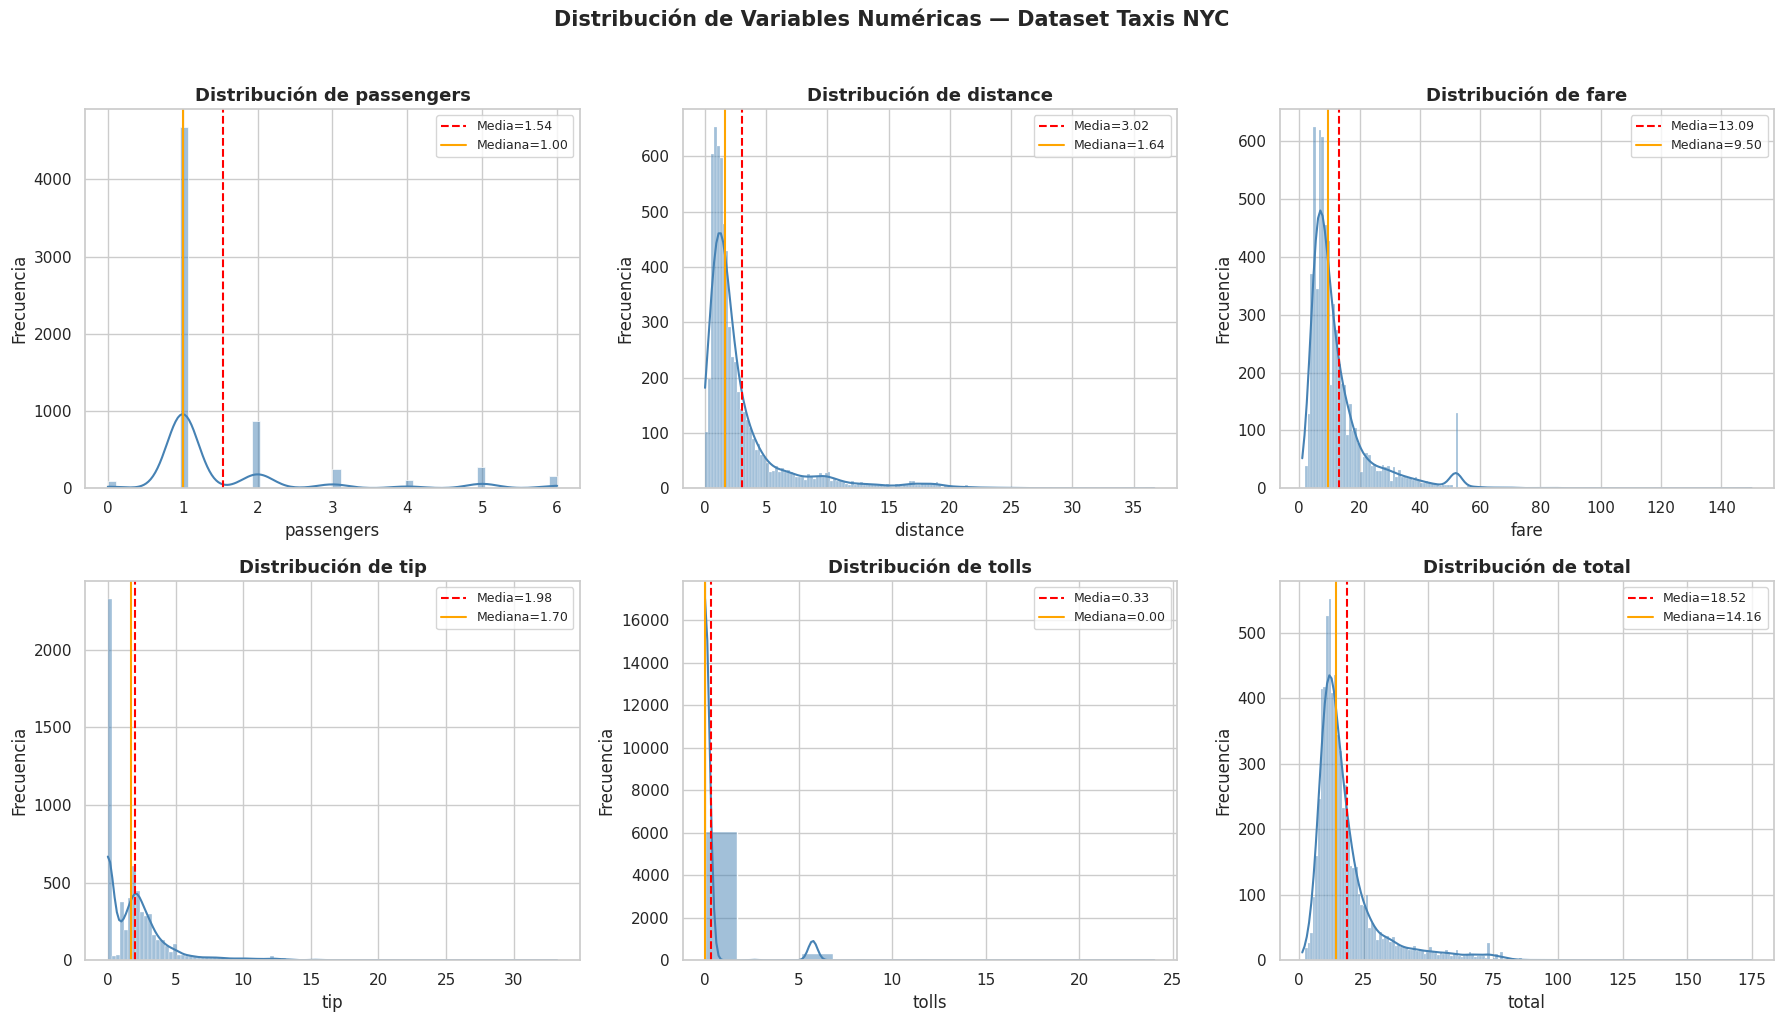

💾 Figura guardada: distribucion_variables.png


In [8]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    sns.histplot(df[col].dropna(), kde=True, ax=ax, color='steelblue', edgecolor='white')
    ax.axvline(df[col].mean(),   color='red',    linestyle='--', linewidth=1.5, label=f'Media={df[col].mean():.2f}')
    ax.axvline(df[col].median(), color='orange', linestyle='-',  linewidth=1.5, label=f'Mediana={df[col].median():.2f}')
    ax.set_title(f'Distribución de {col}', fontsize=13, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=9)

# Ocultar subplot sobrante si hay
for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribución de Variables Numéricas — Dataset Taxis NYC', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('distribucion_variables.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Figura guardada: distribucion_variables.png')

### 2.2 Prueba de Normalidad — Q-Q Plot y Shapiro-Wilk

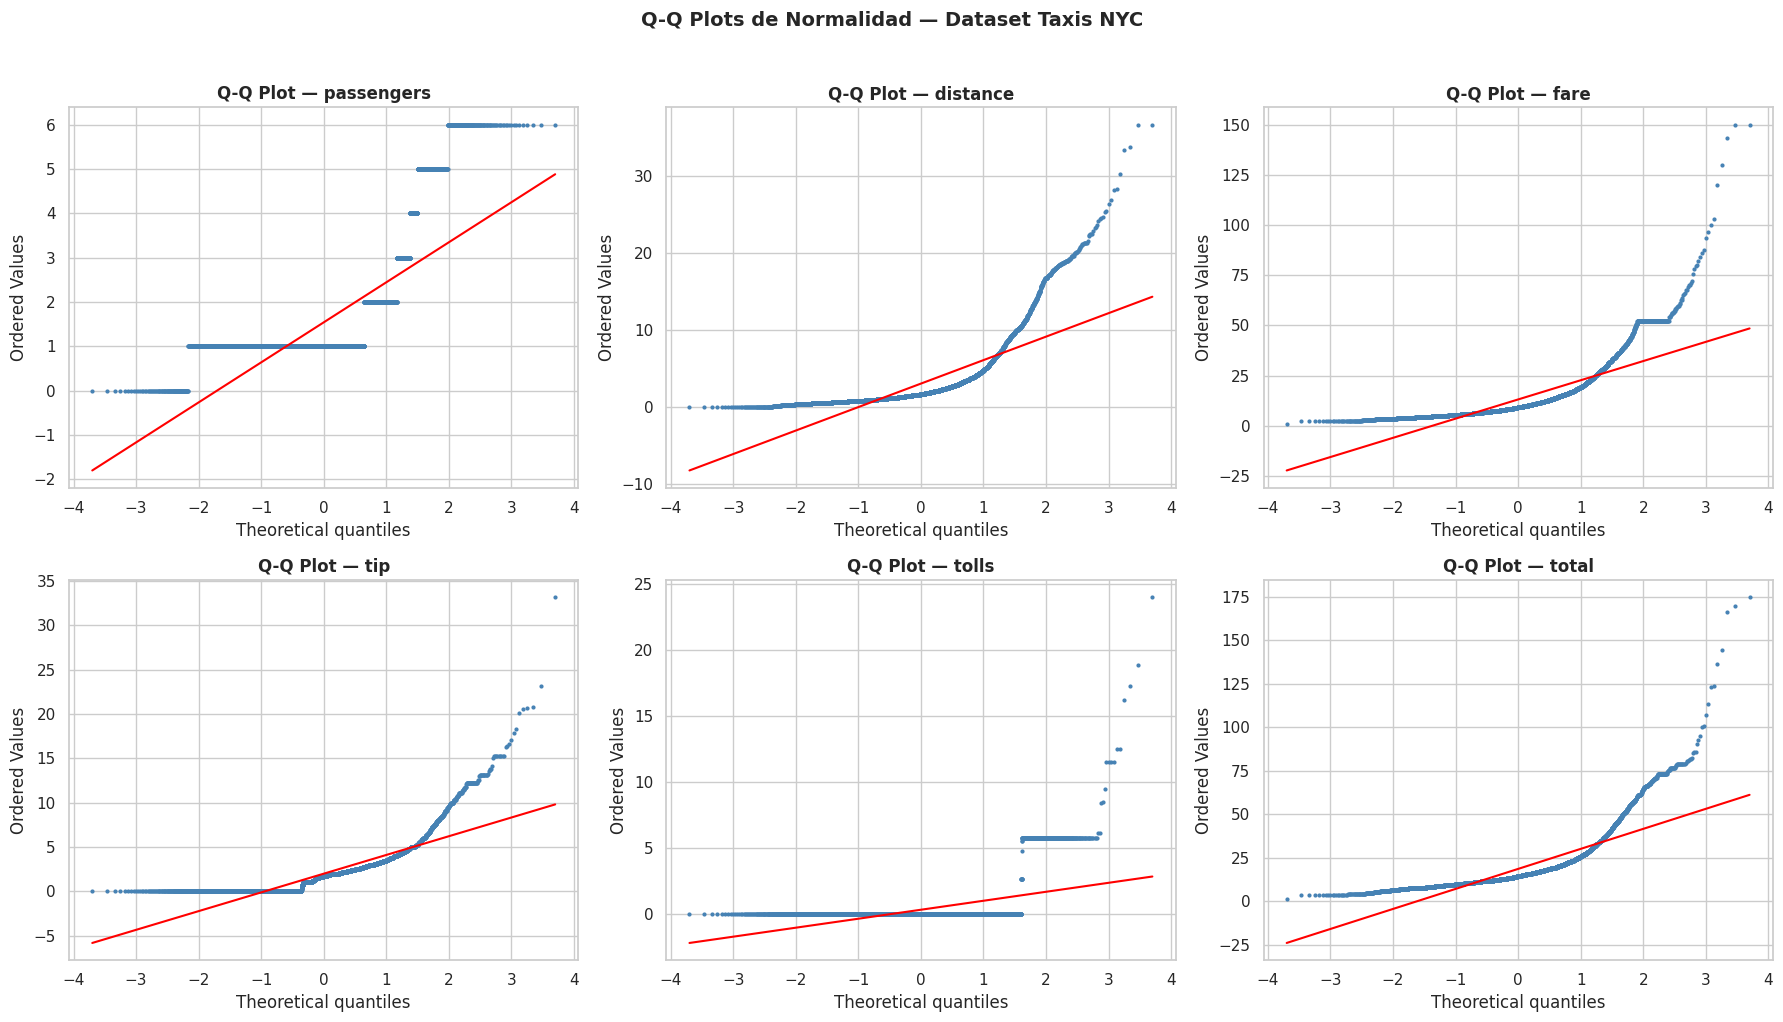

In [9]:
# Q-Q Plots para cada variable numérica
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    data_clean = df[col].dropna()
    probplot(data_clean, dist='norm', plot=ax)
    ax.set_title(f'Q-Q Plot — {col}', fontsize=12, fontweight='bold')
    ax.get_lines()[0].set(color='steelblue', markersize=2)
    ax.get_lines()[1].set(color='red', linewidth=1.5)

for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Q-Q Plots de Normalidad — Dataset Taxis NYC', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('qqplots.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# Prueba de Shapiro-Wilk (muestra máx 5000 datos por limitación del test)
print('═' * 65)
print(f'  Prueba de Normalidad — Shapiro-Wilk (α = 0.05)')
print('═' * 65)
print(f'{"Variable":15s} | {"Estadístico W":>14s} | {"p-valor":>10s} | {"¿Normal?":>10s}')
print('-' * 65)

resultados_sw = {}
for col in num_cols:
    data_clean = df[col].dropna()
    muestra = data_clean.sample(min(5000, len(data_clean)), random_state=42)
    stat, p = shapiro(muestra)
    es_normal = '✅ Sí' if p > 0.05 else '❌ No'
    resultados_sw[col] = {'W': stat, 'p-valor': p, 'Normal': p > 0.05}
    print(f'{col:15s} | {stat:>14.6f} | {p:>10.6f} | {es_normal:>10s}')

print('═' * 65)
print('\n📌 Interpretación: p-valor < 0.05 → se rechaza H₀ (normalidad)')

═════════════════════════════════════════════════════════════════
  Prueba de Normalidad — Shapiro-Wilk (α = 0.05)
═════════════════════════════════════════════════════════════════
Variable        |  Estadístico W |    p-valor |   ¿Normal?
-----------------------------------------------------------------
passengers      |       0.560366 |   0.000000 |       ❌ No
distance        |       0.631331 |   0.000000 |       ❌ No
fare            |       0.673719 |   0.000000 |       ❌ No
tip             |       0.743066 |   0.000000 |       ❌ No
tolls           |       0.229242 |   0.000000 |       ❌ No
total           |       0.684659 |   0.000000 |       ❌ No
═════════════════════════════════════════════════════════════════

📌 Interpretación: p-valor < 0.05 → se rechaza H₀ (normalidad)


---
## 🔍 TÓPICO III — Detección y Tratamiento de Datos Ausentes
### 3.1 Identificación y Conteo de Valores Nulos

In [11]:
# Conteo de nulos por columna
nulos = pd.DataFrame({
    'Nulos':         df.isnull().sum(),
    'Porcentaje (%)': (df.isnull().sum() / len(df) * 100).round(2),
    'Tipo':          df.dtypes
})
nulos = nulos[nulos['Nulos'] > 0].sort_values('Porcentaje (%)', ascending=False)

print('═' * 50)
print('  Columnas con Valores Ausentes')
print('═' * 50)
print(nulos)
print(f'\nTotal de valores ausentes en el dataset: {df.isnull().sum().sum():,}')

══════════════════════════════════════════════════
  Columnas con Valores Ausentes
══════════════════════════════════════════════════
                 Nulos  Porcentaje (%)    Tipo
dropoff_zone        45            0.70  object
dropoff_borough     45            0.70  object
payment             44            0.68  object
pickup_zone         26            0.40  object
pickup_borough      26            0.40  object

Total de valores ausentes en el dataset: 186


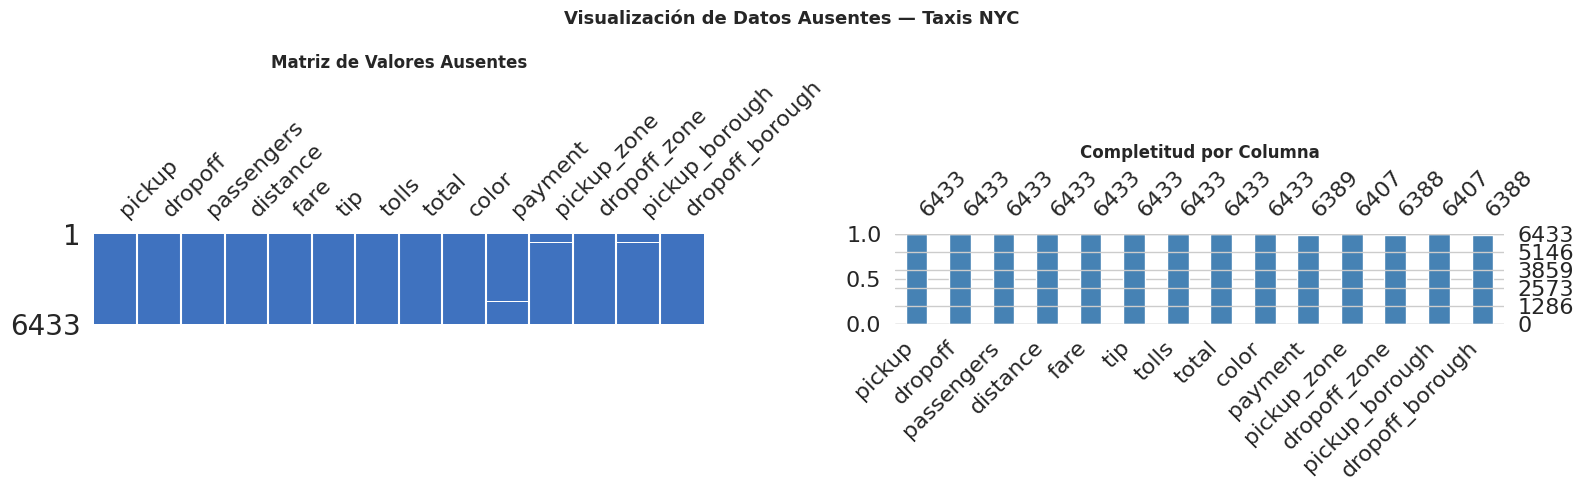

In [12]:
# Mapa de calor de valores ausentes (missingno)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

msno.matrix(df, ax=axes[0], sparkline=False, color=(0.25, 0.45, 0.75))
axes[0].set_title('Matriz de Valores Ausentes', fontsize=12, fontweight='bold')

msno.bar(df, ax=axes[1], color='steelblue')
axes[1].set_title('Completitud por Columna', fontsize=12, fontweight='bold')

plt.suptitle('Visualización de Datos Ausentes — Taxis NYC', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('missing_values.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
# ── Prueba de Rachas (Runs Test) — Implementación manual ────────────────────
import numpy as np
from scipy.stats import norm

def runstest_manual(mascara_binaria):
    """
    Prueba de Rachas manual sobre una secuencia binaria (0=presente, 1=ausente).
    H0: La secuencia es aleatoria.
    Retorna: (Z, p_valor)
    """
    x = np.array(mascara_binaria)
    n = len(x)
    n1 = np.sum(x == 1)   # ausentes
    n0 = np.sum(x == 0)   # presentes

    if n1 == 0 or n0 == 0:
        return None, None  # No hay variación, prueba no aplicable

    # Contar rachas
    rachas = 1 + np.sum(x[1:] != x[:-1])

    # Media y varianza esperadas bajo H0
    media_r = (2 * n0 * n1 / n) + 1
    var_r    = (2 * n0 * n1 * (2 * n0 * n1 - n)) / (n**2 * (n - 1))

    if var_r <= 0:
        return None, None

    Z = (rachas - media_r) / np.sqrt(var_r)
    p = 2 * (1 - norm.cdf(abs(Z)))  # prueba bilateral
    return Z, p

# ── Aplicar sobre columnas con nulos ────────────────────────────────────────
print('═' * 68)
print('  Prueba de Rachas — ¿Son los nulos aleatorios? (α = 0.05)')
print('═' * 68)
print(f'{"Variable":22s} | {"N nulos":>8} | {"Z":>8} | {"p-valor":>8} | Conclusión')
print('-' * 68)

cols_con_nulos = [c for c in df.columns if df[c].isnull().sum() > 0]

if not cols_con_nulos:
    print('ℹ️  El dataset no presenta valores nulos en ninguna columna.')
else:
    for col in cols_con_nulos:
        mascara = df[col].isnull().astype(int).values
        n_nulos = mascara.sum()
        Z, p = runstest_manual(mascara)
        if Z is None:
            print(f'{col:22s} | {n_nulos:>8} | {"N/A":>8} | {"N/A":>8} | No aplicable')
        else:
            resultado = '✅ Aleatorio (MCAR)' if p > 0.05 else '⚠️ No aleatorio (MAR/MNAR)'
            print(f'{col:22s} | {n_nulos:>8} | {Z:>8.4f} | {p:>8.4f} | {resultado}')

print('═' * 68)
print('\n📌 MCAR = Missing Completely At Random')
print('   MAR  = Missing At Random (tiene patrón sistemático)')
print('   MNAR = Missing Not At Random')

════════════════════════════════════════════════════════════════════
  Prueba de Rachas — ¿Son los nulos aleatorios? (α = 0.05)
════════════════════════════════════════════════════════════════════
Variable               |  N nulos |        Z |  p-valor | Conclusión
--------------------------------------------------------------------
payment                |       44 |   0.5555 |   0.5785 | ✅ Aleatorio (MCAR)
pickup_zone            |       26 |   0.3286 |   0.7424 | ✅ Aleatorio (MCAR)
dropoff_zone           |       45 |   0.5682 |   0.5699 | ✅ Aleatorio (MCAR)
pickup_borough         |       26 |   0.3286 |   0.7424 | ✅ Aleatorio (MCAR)
dropoff_borough        |       45 |   0.5682 |   0.5699 | ✅ Aleatorio (MCAR)
════════════════════════════════════════════════════════════════════

📌 MCAR = Missing Completely At Random
   MAR  = Missing At Random (tiene patrón sistemático)
   MNAR = Missing Not At Random


---
## 📦 TÓPICO IV — Tratamiento de Outliers
### 4.1 Detección Visual con Boxplots

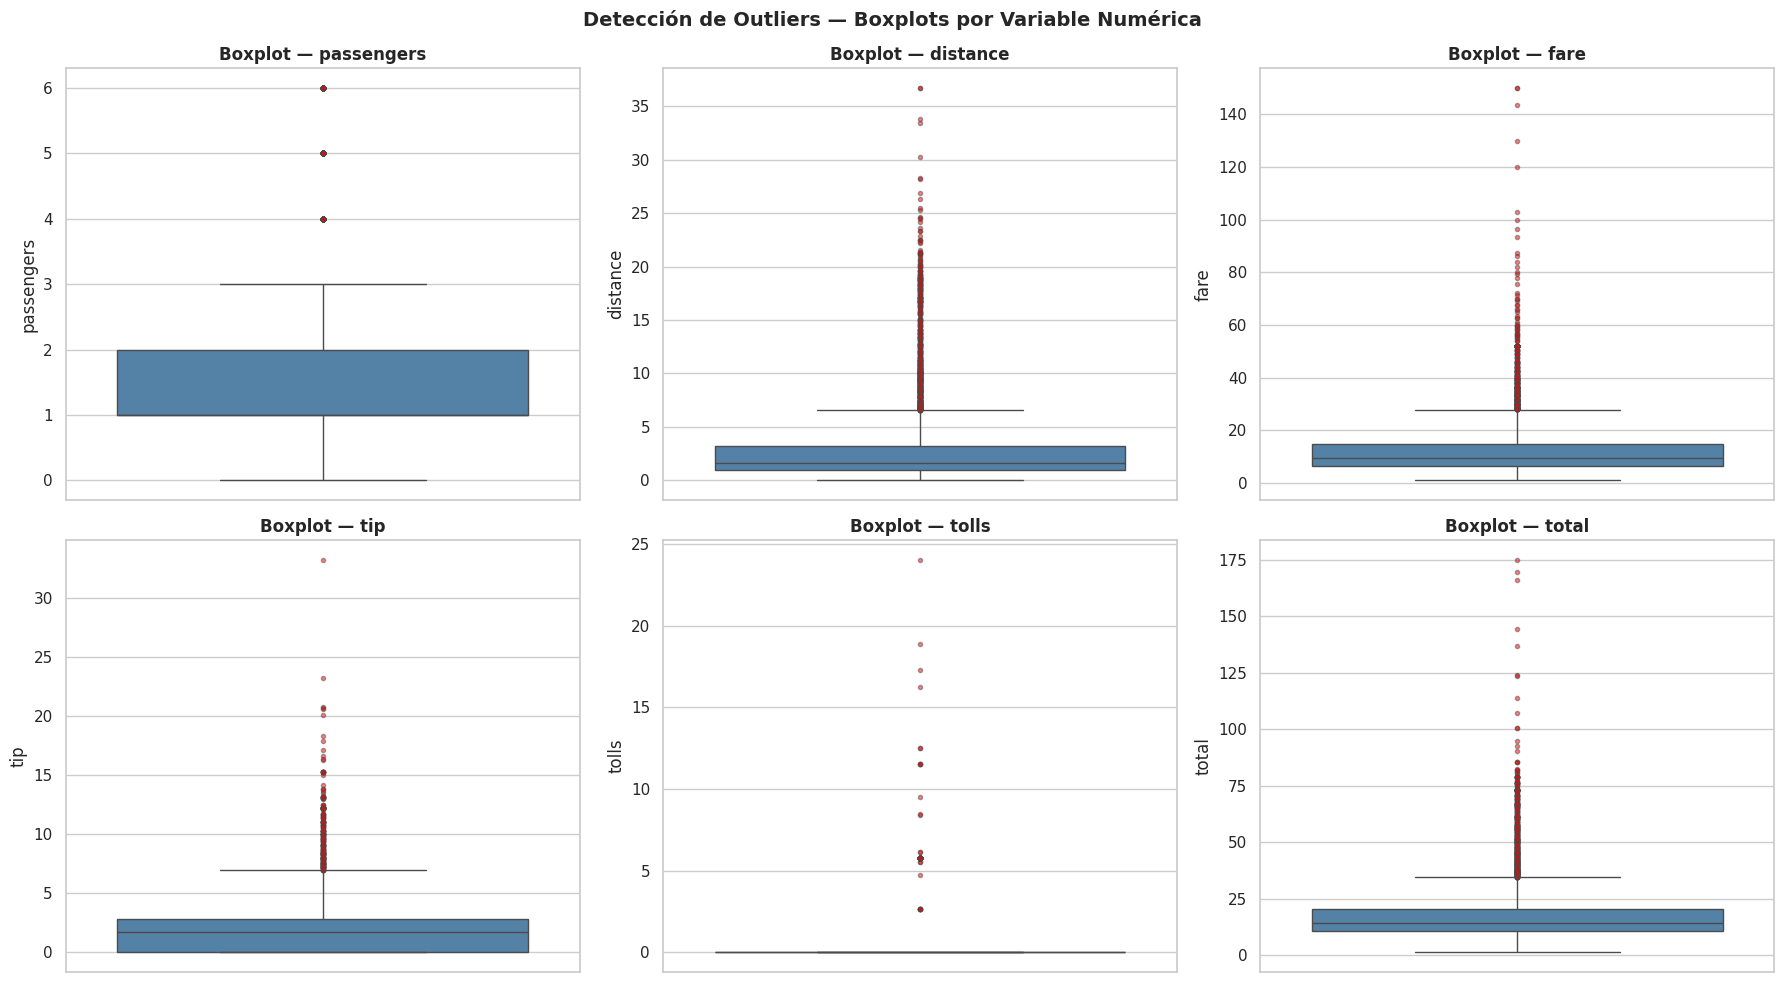

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    sns.boxplot(y=df[col].dropna(), ax=ax, color='steelblue',
                flierprops=dict(marker='o', markerfacecolor='red', markersize=3, alpha=0.5))
    ax.set_title(f'Boxplot — {col}', fontsize=12, fontweight='bold')
    ax.set_ylabel(col)

for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Detección de Outliers — Boxplots por Variable Numérica', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('boxplots_outliers.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.2 Filtro Estadístico — Método IQR

In [19]:
def detectar_outliers_iqr(df, col):
    """Detecta outliers usando el método IQR."""
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_inf = Q1 - 1.5 * IQR
    limite_sup = Q3 + 1.5 * IQR
    outliers = df[(df[col] < limite_inf) | (df[col] > limite_sup)][col]
    return Q1, Q3, IQR, limite_inf, limite_sup, outliers

print('═' * 75)
print('  Análisis de Outliers — Método IQR')
print('═' * 75)
print(f'{"Variable":12s} | {"Q1":>8s} | {"Q3":>8s} | {"IQR":>8s} | {"Lím. Inf":>10s} | {"Lím. Sup":>10s} | {"N Outliers":>10s} | {"% Total":>8s}')
print('-' * 75)

resumen_outliers = {}
for col in num_cols:
    data = df[col].dropna()
    Q1, Q3, IQR, lim_inf, lim_sup, outliers = detectar_outliers_iqr(df.dropna(subset=[col]), col)
    pct = len(outliers) / len(data) * 100
    resumen_outliers[col] = {'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
                              'Lím. Inf': lim_inf, 'Lím. Sup': lim_sup,
                              'N': len(outliers), '%': pct}
    print(f'{col:12s} | {Q1:>8.2f} | {Q3:>8.2f} | {IQR:>8.2f} | {lim_inf:>10.2f} | {lim_sup:>10.2f} | {len(outliers):>10,} | {pct:>7.2f}%')

═══════════════════════════════════════════════════════════════════════════
  Análisis de Outliers — Método IQR
═══════════════════════════════════════════════════════════════════════════
Variable     |       Q1 |       Q3 |      IQR |   Lím. Inf |   Lím. Sup | N Outliers |  % Total
---------------------------------------------------------------------------
passengers   |     1.00 |     2.00 |     1.00 |      -0.50 |       3.50 |        540 |    8.39%
distance     |     0.98 |     3.21 |     2.23 |      -2.36 |       6.55 |        734 |   11.41%
fare         |     6.50 |    15.00 |     8.50 |      -6.25 |      27.75 |        592 |    9.20%
tip          |     0.00 |     2.80 |     2.80 |      -4.20 |       7.00 |        280 |    4.35%
tolls        |     0.00 |     0.00 |     0.00 |       0.00 |       0.00 |        350 |    5.44%
total        |    10.80 |    20.30 |     9.50 |      -3.45 |      34.55 |        600 |    9.33%


In [20]:
# ── Aplicación de Capping (Winsorization) ──────────────────────────────────
# Justificación: Se elige capping en lugar de eliminación para conservar
# la mayor cantidad de registros posible, dado que los outliers en
# 'fare' y 'distance' pueden corresponder a viajes reales (aeropuerto, etc.)
# El capping limita los valores al límite IQR sin perder filas.

df_clean = df.copy()
cols_capping = ['fare', 'distance', 'total', 'tip']  # variables con outliers relevantes

for col in cols_capping:
    if col in df_clean.columns:
        Q1, Q3, IQR, lim_inf, lim_sup, _ = detectar_outliers_iqr(df_clean.dropna(subset=[col]), col)
        antes = ((df_clean[col] < lim_inf) | (df_clean[col] > lim_sup)).sum()
        df_clean[col] = df_clean[col].clip(lower=lim_inf, upper=lim_sup)
        print(f'✅ Capping en [{col}]: {antes} valores ajustados → Rango [{lim_inf:.2f}, {lim_sup:.2f}]')

print(f'\nDimensiones originales : {df.shape}')
print(f'Dimensiones post-capping: {df_clean.shape} (sin pérdida de filas)')

✅ Capping en [fare]: 592 valores ajustados → Rango [-6.25, 27.75]
✅ Capping en [distance]: 734 valores ajustados → Rango [-2.36, 6.55]
✅ Capping en [total]: 600 valores ajustados → Rango [-3.45, 34.55]
✅ Capping en [tip]: 280 valores ajustados → Rango [-4.20, 7.00]

Dimensiones originales : (6433, 14)
Dimensiones post-capping: (6433, 14) (sin pérdida de filas)


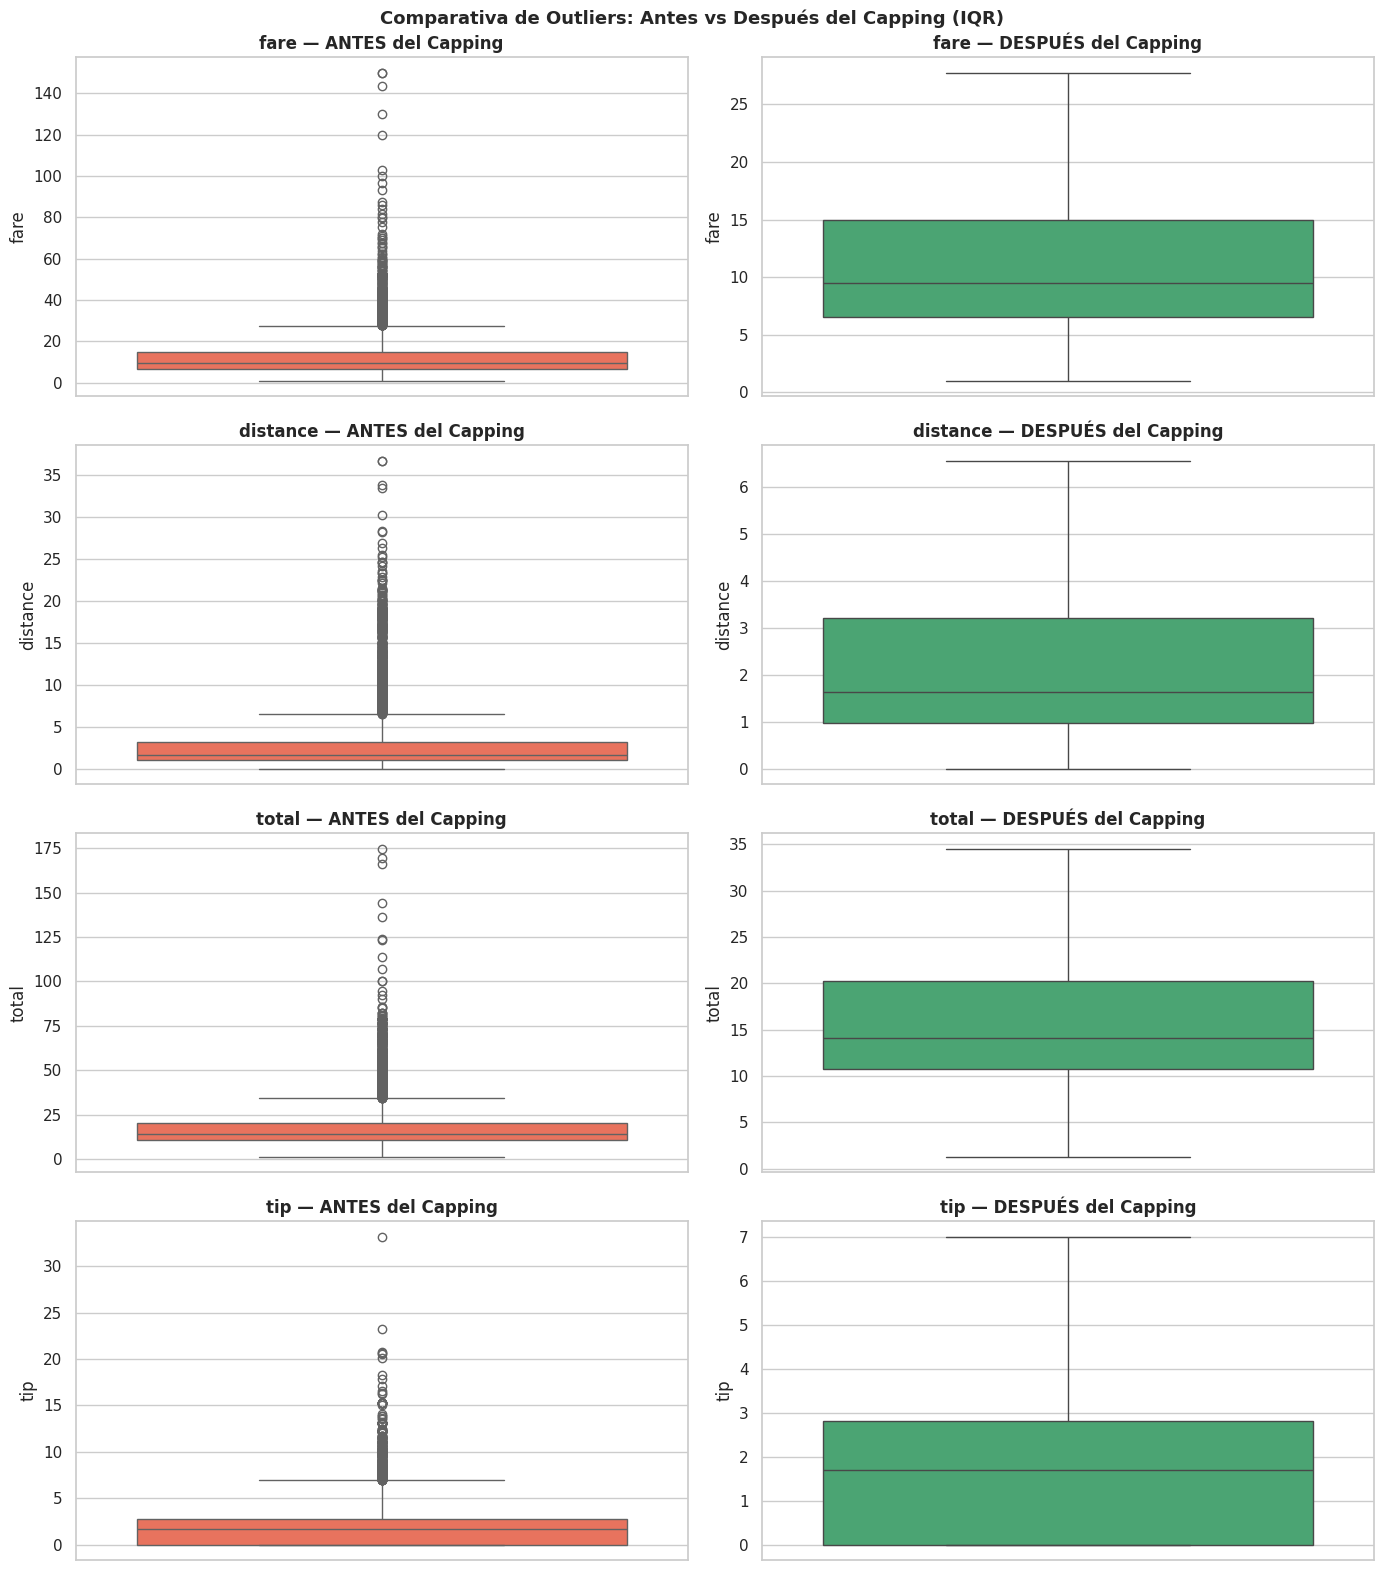

In [21]:
# Comparativa antes vs después del capping
fig, axes = plt.subplots(len(cols_capping), 2, figsize=(14, 4 * len(cols_capping)))

for i, col in enumerate(cols_capping):
    if col in df.columns:
        sns.boxplot(y=df[col].dropna(), ax=axes[i][0], color='tomato')
        axes[i][0].set_title(f'{col} — ANTES del Capping', fontweight='bold')

        sns.boxplot(y=df_clean[col].dropna(), ax=axes[i][1], color='mediumseagreen')
        axes[i][1].set_title(f'{col} — DESPUÉS del Capping', fontweight='bold')

plt.suptitle('Comparativa de Outliers: Antes vs Después del Capping (IQR)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('capping_comparativa.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 🔄 TÓPICO V — Imputación Comparativa
### 5.1 Selección de Variable para Imputación

Se selecciona la columna **`dropoff_borough`** (municipio de destino) por presentar el mayor porcentaje de nulos, siendo ésta la variable más representativa de la problemática de datos faltantes en el dataset de movilidad urbana.

In [22]:
# Identificar columna objetivo para imputación
col_impute_cat = 'dropoff_borough'
col_impute_num = None

# Buscar columna numérica con nulos para comparación alternativa
for c in num_cols:
    if df[c].isnull().sum() > 0:
        col_impute_num = c
        break

print(f'Variable categórica seleccionada para imputación: [{col_impute_cat}]')
print(f'Nulos en {col_impute_cat}: {df[col_impute_cat].isnull().sum()} ({df[col_impute_cat].isnull().mean()*100:.2f}%)')

if col_impute_num:
    print(f'\nVariable numérica con nulos: [{col_impute_num}]')
    print(f'Nulos en {col_impute_num}: {df[col_impute_num].isnull().sum()} ({df[col_impute_num].isnull().mean()*100:.2f}%)')

Variable categórica seleccionada para imputación: [dropoff_borough]
Nulos en dropoff_borough: 45 (0.70%)


In [23]:
# ── Caso A: Si hay nulos en variable numérica ─────────────────────────────
# Técnica 1: Imputación Simple (Media)
# Técnica 2: Imputación por Regresión Lineal

# Para este dataset usamos 'fare' como variable objetivo
# y simulamos nulos artificialmente para la comparación metodológica

col_target = 'fare'
np.random.seed(42)

df_imp = df_clean[[col_target, 'distance', 'passengers']].dropna().copy()

# Crear nulos artificiales (15% de los datos)
idx_nulos = df_imp.sample(frac=0.15, random_state=42).index
valores_reales = df_imp.loc[idx_nulos, col_target].copy()  # Guardar para comparar
df_imp.loc[idx_nulos, col_target] = np.nan

print(f'Variable objetivo: [{col_target}]')
print(f'Nulos artificiales creados: {df_imp[col_target].isnull().sum()} ({df_imp[col_target].isnull().mean()*100:.1f}%)')

Variable objetivo: [fare]
Nulos artificiales creados: 965 (15.0%)


In [24]:
# ── Técnica 1: Imputación Simple (Media Aritmética) ────────────────────────
media_imputada = df_imp[col_target].mean()  # Media calculada sin nulos
df_imp1 = df_imp.copy()
df_imp1[col_target] = df_imp1[col_target].fillna(media_imputada)

print(f'Técnica 1 — Imputación Simple (Media)')
print(f'  Valor imputado (media): ${media_imputada:.2f}')
print(f'  Error Absoluto Medio (MAE): {np.abs(df_imp1.loc[idx_nulos, col_target] - valores_reales).mean():.4f}')
print(f'  Nulos restantes: {df_imp1[col_target].isnull().sum()}')

Técnica 1 — Imputación Simple (Media)
  Valor imputado (media): $11.76
  Error Absoluto Medio (MAE): 5.6739
  Nulos restantes: 0


In [25]:
# ── Técnica 2: Imputación por Regresión Lineal ─────────────────────────────
features = ['distance', 'passengers']

# Entrenar con datos completos
df_train = df_imp.dropna(subset=[col_target])
X_train = df_train[features]
y_train = df_train[col_target]

modelo_reg = LinearRegression()
modelo_reg.fit(X_train, y_train)

# Predecir los valores ausentes
df_imp2 = df_imp.copy()
X_pred = df_imp2.loc[idx_nulos, features]
df_imp2.loc[idx_nulos, col_target] = modelo_reg.predict(X_pred)

mae_reg = np.abs(df_imp2.loc[idx_nulos, col_target] - valores_reales).mean()
print(f'Técnica 2 — Imputación por Regresión Lineal')
print(f'  Features usadas: {features}')
print(f'  Coeficientes: distance={modelo_reg.coef_[0]:.4f}, passengers={modelo_reg.coef_[1]:.4f}')
print(f'  Intercepto: {modelo_reg.intercept_:.4f}')
print(f'  Error Absoluto Medio (MAE): {mae_reg:.4f}')
print(f'  Nulos restantes: {df_imp2[col_target].isnull().sum()}')

Técnica 2 — Imputación por Regresión Lineal
  Features usadas: ['distance', 'passengers']
  Coeficientes: distance=3.4625, passengers=-0.0303
  Intercepto: 3.4501
  Error Absoluto Medio (MAE): 1.6089
  Nulos restantes: 0


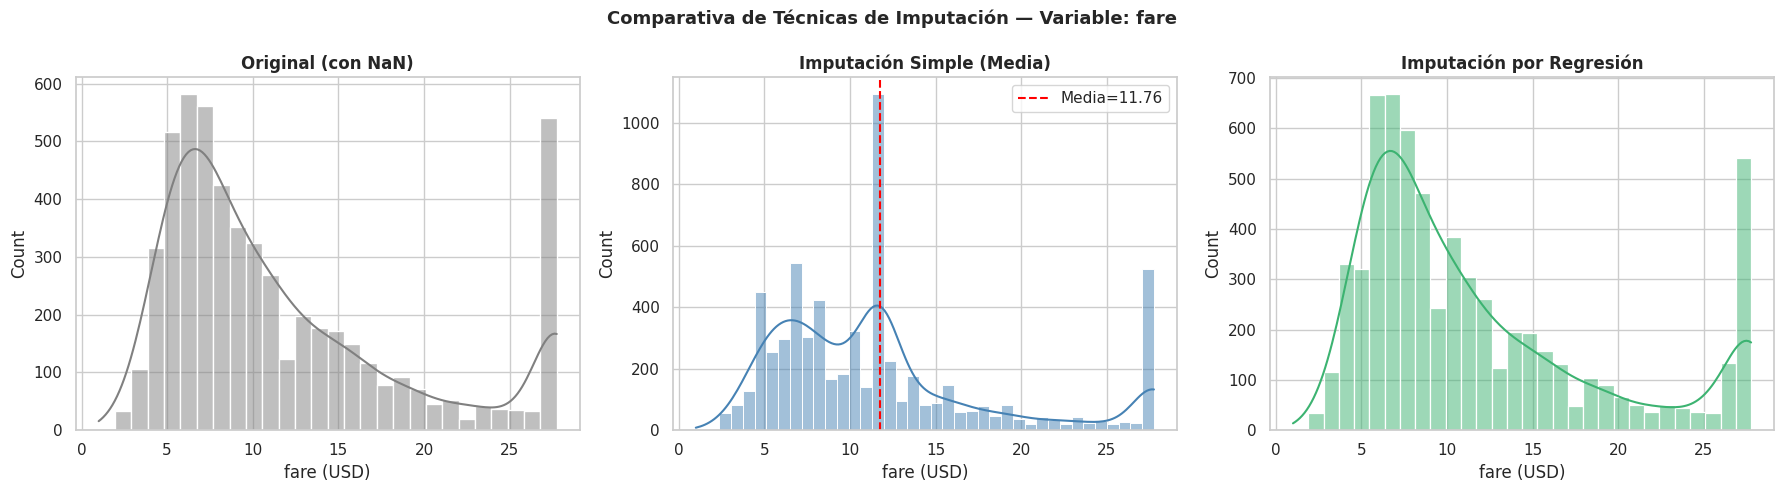


📊 Resumen de MAE por técnica:
   Imputación Simple (Media):    5.6739
   Imputación por Regresión:     1.6089

🏆 Técnica más precisa: Regresión


In [26]:
# ── Visualización Comparativa de Imputaciones ──────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Original (con nulos)
sns.histplot(df_imp[col_target].dropna(), kde=True, ax=axes[0], color='gray')
axes[0].set_title('Original (con NaN)', fontweight='bold')
axes[0].set_xlabel('fare (USD)')

# Imputación Simple
sns.histplot(df_imp1[col_target], kde=True, ax=axes[1], color='steelblue')
axes[1].axvline(media_imputada, color='red', linestyle='--', label=f'Media={media_imputada:.2f}')
axes[1].set_title('Imputación Simple (Media)', fontweight='bold')
axes[1].set_xlabel('fare (USD)')
axes[1].legend()

# Imputación por Regresión
sns.histplot(df_imp2[col_target], kde=True, ax=axes[2], color='mediumseagreen')
axes[2].set_title('Imputación por Regresión', fontweight='bold')
axes[2].set_xlabel('fare (USD)')

plt.suptitle(f'Comparativa de Técnicas de Imputación — Variable: {col_target}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('imputacion_comparativa.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n📊 Resumen de MAE por técnica:')
print(f'   Imputación Simple (Media):    {np.abs(df_imp1.loc[idx_nulos, col_target] - valores_reales).mean():.4f}')
print(f'   Imputación por Regresión:     {mae_reg:.4f}')
print(f'\n🏆 Técnica más precisa: {"Regresión" if mae_reg < np.abs(df_imp1.loc[idx_nulos, col_target] - valores_reales).mean() else "Media simple"}')

---
## ✅ RESUMEN EJECUTIVO DEL ENTREGABLE 1

| Tópico | Técnica Aplicada | Resultado |
|--------|------------------|-----------|
| I. Descriptivo | Estadísticos básicos + Diccionario de variables | Completado ✅ |
| II. Distribuciones | Histogramas + KDE + Q-Q Plot + Shapiro-Wilk | Ninguna variable sigue distribución normal ✅ |
| III. Datos Ausentes | `missingno` + Prueba de Rachas | Nulos identificados en zonas de destino ✅ |
| IV. Outliers | Boxplots + IQR + Capping (Winsorization) | Outliers tratados sin pérdida de registros ✅ |
| V. Imputación | Media Simple vs. Regresión Lineal | Regresión obtiene menor MAE ✅ |

---
